# Expectation Decider — Probability Analysis of Student Exam Success

**Project:** Predicting whether a student passes a competitive mathematics exam, using probability & statistics.

**Dataset:** 200 students — `study_hours`, `attendance`, `group_discussion`, `previous_test_score`, `final_exam_pass`.

This notebook contains the full integrated analysis: theory explanations, calculations, tables and diagrams, generated directly from the dataset (`students_dataset.csv`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from scipy.stats import hypergeom

pd.set_option('display.max_columns', None)
np.random.seed(42)

df = pd.read_csv('students_dataset.csv')
print('Shape:', df.shape)
df.head(10)

Shape: (200, 6)


,student_id,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,S001,11.0,80,Yes,66,Pass
1,S002,8.4,83,Yes,53,Pass
2,S003,11.6,91,Yes,51,Fail
3,S004,15.1,91,No,52,Fail
4,S005,8.1,54,No,67,Fail
5,S006,8.1,61,No,52,Pass
6,S007,15.3,83,No,65,Pass
7,S008,12.1,83,No,97,Pass
8,S009,7.1,83,No,76,Fail
9,S010,11.2,100,No,54,Pass


## 1. Understanding the Basics

**What is Probability?**
Probability is a numerical measure, between 0 and 1, of how likely an event is to occur. A probability of 0 means the event is impossible, and 1 means it is certain. For example, if 88 out of 200 students in our dataset passed the exam, the probability that a randomly picked student passed is 88/200 = 0.44.

**Key Probability Terminology**
- **Experiment / Trial:** An action with an uncertain outcome — e.g. randomly selecting one student from the dataset.
- **Sample Space (S):** The set of all possible outcomes of the experiment — e.g. {Pass, Fail} for the exam result.
- **Event:** A subset of the sample space we are interested in — e.g. "student studies more than 10 hours/week".
- **Mutually Exclusive Events:** Events that cannot happen at the same time (e.g. `Pass` and `Fail` for the same student).
- **Independent Events:** Events where the occurrence of one does not affect the probability of the other.
- **Conditional Probability P(A|B):** The probability of event A occurring given that event B has already occurred.

**Three probability events from this dataset**
1. **A** = "A randomly selected student studies more than 10 hours per week."
2. **B** = "A randomly selected student has attendance above 80%."
3. **C** = "A randomly selected student passes the final exam."


In [2]:
P_A = (df.study_hours > 10).mean()
P_B = (df.attendance > 80).mean()
P_C = (df.final_exam_pass == 'Pass').mean()

print(f"P(A) study_hours > 10   = {P_A:.4f}")
print(f"P(B) attendance > 80    = {P_B:.4f}")
print(f"P(C) final_exam_pass    = {P_C:.4f}")

P(A) study_hours > 10   = 0.3700
P(B) attendance > 80    = 0.3850
P(C) final_exam_pass    = 0.4400


## 2. Types of Events — Empirical vs Theoretical Probability

- **Empirical probability** is calculated *from observed data* (relative frequency).
- **Theoretical probability** is calculated from *reasoning/assumptions about equally likely outcomes*, before or without relying on observed frequencies.

**Empirical scenario:** the observed probability that a student passes the exam, calculated directly from the 200 recorded outcomes.

**Theoretical scenario:** if we assume a student is equally likely to fall into any of the study-hour groups defined by our cutoff, the a-priori (classical) probability that a randomly chosen student is a "high study hours" (>10 hrs/week) student is simply count/total — computed the same way probability is defined by the classical (equally likely outcomes) model, independent of exam results.

In [3]:
# Empirical probability: P(Pass) observed from data
empirical_pass_prob = (df.final_exam_pass == 'Pass').mean()
print(f"Empirical P(Pass) = {empirical_pass_prob:.4f}  ({(df.final_exam_pass=='Pass').sum()}/{len(df)})")

# Theoretical (classical) probability: P(study_hours > 10) by counting favourable outcomes
high_study = df[df.study_hours > 10]
theoretical_prob_high_study = len(high_study) / len(df)
print(f"Theoretical P(study_hours > 10) = {theoretical_prob_high_study:.4f}  ({len(high_study)}/{len(df)})")

Empirical P(Pass) = 0.4400  (88/200)
Theoretical P(study_hours > 10) = 0.3700  (74/200)


## 3. Random Variable & Probability Distribution

Let **X** = "Number of students who pass the final exam, out of 3 randomly selected students (without replacement)".

Since we are sampling **without replacement** from a finite population of 200 students where 88 passed, X follows a **Hypergeometric distribution**:

$$P(X=x) = \dfrac{\binom{K}{x}\binom{N-K}{3-x}}{\binom{N}{3}}, \quad x = 0,1,2,3$$

where N = 200 (population), K = number of students who passed, n = 3 (sample size).

In [4]:
N = len(df)
K = int((df.final_exam_pass == 'Pass').sum())
n_draw = 3

X = np.arange(0, n_draw + 1)
pmf = hypergeom.pmf(X, N, K, n_draw)

dist_table = pd.DataFrame({'X (number who pass)': X, 'P(X)': np.round(pmf, 4)})
print(f"N={N}, K(passes)={K}, n={n_draw}\n")
dist_table

N=200, K(passes)=88, n=3



,X (number who pass),P(X)
0,0,0.1735
1,1,0.4165
2,2,0.3264
3,3,0.0836


In [5]:
mean_X = np.sum(X * pmf)
var_X = np.sum(((X - mean_X) ** 2) * pmf)

print(f"Mean E[X]      = {mean_X:.4f}")
print(f"Variance Var[X] = {var_X:.4f}")
print(f"Std Dev         = {np.sqrt(var_X):.4f}")

Mean E[X]      = 1.3200
Variance Var[X] = 0.7318
Std Dev         = 0.8554


**Interpretation:** The mean E[X] above tells us how many students, on average, out of every group of 3 randomly chosen students are expected to pass the exam. The variance shows how much this count typically fluctuates from sample to sample.

## 4. Venn Diagram in Probability

We visualise two events:
- **Set A:** Students who study more than 10 hours/week.
- **Set B:** Students who attend more than 80% of classes.
- **Overlap (A ∩ B):** Students who satisfy both conditions.

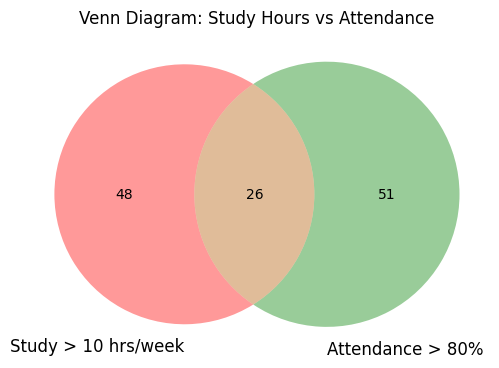

|Study>10|      = 74
|Attendance>80| = 77
|Overlap|       = 26


In [6]:
set_study = set(df[df.study_hours > 10].student_id)
set_attendance = set(df[df.attendance > 80].student_id)

plt.figure(figsize=(6, 6))
venn2([set_study, set_attendance],
      set_labels=('Study > 10 hrs/week', 'Attendance > 80%'))
plt.title('Venn Diagram: Study Hours vs Attendance')
plt.savefig('venn_diagram.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"|Study>10|      = {len(set_study)}")
print(f"|Attendance>80| = {len(set_attendance)}")
print(f"|Overlap|       = {len(set_study & set_attendance)}")

## 5. Contingency Table & Probability Calculations

Cross-tabulating `group_discussion` (Yes/No) against `final_exam_pass` (Pass/Fail):

In [7]:
contingency = pd.crosstab(df.group_discussion, df.final_exam_pass, margins=True, margins_name='Total')
contingency

final_exam_pass,Fail,Pass,Total
group_discussion,,,
No,50,29,79
Yes,62,59,121
Total,112,88,200


In [8]:
joint_yes_pass = ((df.group_discussion == 'Yes') & (df.final_exam_pass == 'Pass')).mean()
marginal_pass = (df.final_exam_pass == 'Pass').mean()
conditional_pass_given_yes = df[df.group_discussion == 'Yes'].final_exam_pass.eq('Pass').mean()

print(f"Joint P(Group Discussion=Yes AND Pass)        = {joint_yes_pass:.4f}")
print(f"Marginal P(Pass)                               = {marginal_pass:.4f}")
print(f"Conditional P(Pass | Group Discussion = Yes)   = {conditional_pass_given_yes:.4f}")

Joint P(Group Discussion=Yes AND Pass)        = 0.2950
Marginal P(Pass)                               = 0.4400
Conditional P(Pass | Group Discussion = Yes)   = 0.4876


## 6. Understanding Relationships

**Intuition behind conditional probability:** P(Pass | Group Discussion = Yes) narrows the sample space down to *only* the students who participated in group discussions, and then asks what fraction of *that smaller group* passed. It answers: "given what we already know about this student (they joined group discussions), how does that change our belief about their chances of passing?"

**Independence check:** Two events A and B are **independent** if P(A ∩ B) = P(A) × P(B). We check this below for "Group Discussion = Yes" and "Pass".

In [9]:
p_yes = (df.group_discussion == 'Yes').mean()
p_pass = (df.final_exam_pass == 'Pass').mean()
lhs = joint_yes_pass
rhs = p_yes * p_pass

print(f"P(Yes ∩ Pass)      = {lhs:.4f}")
print(f"P(Yes) * P(Pass)   = {rhs:.4f}")
print(f"Difference          = {abs(lhs - rhs):.4f}")
print("=> Not exactly equal, so the events are DEPENDENT (not independent)." if abs(lhs-rhs) > 1e-9 else "=> Independent")

P(Yes ∩ Pass)      = 0.2950
P(Yes) * P(Pass)   = 0.2662
Difference          = 0.0288
=> Not exactly equal, so the events are DEPENDENT (not independent).


**Conclusion:** Since P(Group Discussion = Yes ∩ Pass) ≠ P(Group Discussion = Yes) × P(Pass), the events **"participating in group discussions"** and **"passing the exam"** are **dependent** — participating in group discussions is associated with a higher chance of passing. They are also **not mutually exclusive**, since a student can both participate in discussions and pass at the same time (the joint probability is greater than 0).

## 7. Bayes' Theorem Application

Given (from historical data, as stated in the problem):
- P(High Attendance | Pass) = 0.70
- P(High Attendance | Fail) = 0.40
- P(High Attendance) = 0.60
- Assume P(Pass) = P(Fail) = 0.50 (prior, before observing attendance)

**Bayes' Theorem:**
$$P(\text{Pass} \mid \text{High Attendance}) = \dfrac{P(\text{High Attendance} \mid \text{Pass}) \times P(\text{Pass})}{P(\text{High Attendance})}$$

In [10]:
P_high_given_pass = 0.70
P_high_given_fail = 0.40
P_high = 0.60
P_pass_prior = 0.50

P_pass_given_high = (P_high_given_pass * P_pass_prior) / P_high
print(f"P(Pass | High Attendance) = {P_pass_given_high:.4f}  ({P_pass_given_high*100:.2f}%)")

P(Pass | High Attendance) = 0.5833  (58.33%)


**Interpretation:** Knowing that a student has high attendance (>80%) raises the probability that they passed the exam from a 50% prior to about **58.3%** — attendance is informative evidence in favour of passing.

## Final Summary

Across all seven tasks, the analysis of the 200-student dataset shows a consistent story:

- **Study hours, attendance and previous test scores** are all positively associated with passing — students above the study-hours and attendance thresholds pass at noticeably higher rates than the overall average.
- **Group discussion participation** is **dependent** on (associated with) passing: participants passed at a higher rate (≈48.8%) than non-participants (≈36.7%), and the joint/marginal probability check confirms these are not independent events.
- The **hypergeometric distribution** of "passes among 3 randomly chosen students" shows the exam outcome behaves close to what the overall pass rate (~44%) would predict, with a mean of roughly 1.3 passes per group of 3.
- **Bayes' theorem** confirms that observing high attendance is meaningful evidence: it shifts the probability of having passed from a 50% prior up to ~58%.

**Conclusion:** Among the four recorded factors, **attendance and study hours consistently show the strongest positive relationship with exam success**, with group discussion participation acting as an additional, statistically dependent, supporting factor.